# HW3 Part 2: Survival Analysis

In this part of the assignment, you will work with censored time-to-event data. The goal is to connect the interpretation of a Cox proportional hazards model with two practical estimators:

- Kaplan-Meier survival curves
- A DeepSurv-style neural network trained with the Cox partial likelihood

Please submit a PDF version of your answers directly in this notebook. For written questions, add your response in the markdown cell below each prompt.

## Learning Goals

By the end of this assignment, you should be able to:

- Interpret hazard ratios from a Cox proportional hazards model.
- Convert a reference survival probability into model-based survival and risk for a new covariate profile.
- Implement the Kaplan-Meier estimator from censored event-time data.
- Train a neural network with the Cox partial likelihood.
- Evaluate a survival model with Harrell's concordance index.

## Dependencies

This notebook uses:

- `numpy`
- `pandas`
- `matplotlib`
- `scikit-learn`
- `scikit-survival`
- `torch`

If `sksurv` is missing, install `scikit-survival` in the same environment that runs this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sksurv.datasets import load_breast_cancer

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(1)
torch.manual_seed(1)

# This tabular survival model is small. Prefer CUDA when available,
# otherwise use CPU. We avoid Apple MPS here because several survival-loss
# operations have incomplete MPS support in current PyTorch builds.
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


# Problem 1: Cox Model Interpretation

A Cox proportional hazards model has the form

$$
h(t \mid x) = h_0(t)\exp(\eta(x)),
$$

where $h_0(t)$ is the baseline hazard and $\eta(x)$ is the linear predictor. For this problem, suppose the linear predictor for prostate cancer recurrence or death is

$$
\eta(\text{age}, \text{smoking}) = -1.04 \cdot \text{age} + 0.20 \cdot \text{smoking},
$$

where age is measured in years and smoking is coded as $0$ for non-smoker and $1$ for smoker.

Use the following reference information:

- The 2-year prostate-cancer-free survival at the reference covariate profile is $S_{\mathrm{ref}}(2) = 0.90$.
- The 5-year prostate-cancer-free survival at the reference covariate profile is $S_{\mathrm{ref}}(5) = 0.75$.
- The reference covariate profile is age $64$ and smoking $0.15$.

For this problem, treat the reference covariate profile as a model reference point. That is,

$$
S(t \mid x) = S_{\mathrm{ref}}(t)^{\exp(\eta(x)-\eta(x_{\mathrm{ref}}))}.
$$

This assumption is included so the model-based risk calculations are well-defined.

## 1.1 Median Survival

Which statement is true about the median time to prostate cancer recurrence or death at the reference covariate profile?

- It is less than 5 years.
- It is more than 5 years.
- It cannot be determined from the information given.

Briefly justify your answer.

**Your answer:**



The median time to prostate cacner recurrence or death is more than 5 years for the reference. Since S(t-median) = 0.5 and S-ref(5) = 0.75, we know that 75% of individuals are still free of prostate cancer recurrence or death at 5 years which means that it would take longer than 5 years to reach 50% (more people dying or recurring cancer).

## 1.2 Hazard Ratio Between Two Patients

Write a formula for the hazard ratio for a 70-year-old smoker compared with a 50-year-old non-smoker.

Your answer should use the Cox model coefficients above and simplify as much as possible.

**Your answer:**



If smoking is 1 for smoker and 0 for non-smoker: 

Hazard Ratio = exp(-20.6)

## 1.3 Hazard Ratio for a $k$-Year Age Increase

Write a formula for the hazard ratio for a $k$-year increase in age while smoking status is held fixed.

Does this hazard ratio depend on whether the person is a smoker? Explain why or why not.

**Your answer:**



Hazard Ratio = exp(1.04k)

This does not depend on whether the person is a smoker if we hold smoking as fixed. The smoking term cancels from the ratio and this leaves only the difference in age and the age coefficient left. This is a result fo having no age-smoking interaction term.

## 1.4 Model-Based Risk

Let risk mean the probability of recurrence or death by time $t$:

$$
\operatorname{Risk}(t \mid x) = 1 - S(t \mid x).
$$

Using the reference survival values above, write formulas for the 2-year and 5-year risks for:

- a 70-year-old smoker
- a 50-year-old non-smoker

You may leave your answer as formulas or compute the numerical values.

**Your answer:**



2-year risk:

Risk(t|x) = 1 - (0.90 ^ exp(-1.04 * age + 0.20 * smoking + 66.53)

    70-year-old-smoker (age = 70, smoking = 1):

    0.00024

    50-year-old non-smoker (age = 50, smoking = 0):

    ~1

5-year risk:

Risk(t|x) = 1 - (0.75 ^ exp(-1.04 * age + 0.20 * smoking + 66.53)

    70-year-old-smoker (age = 70, smoking = 1):

    0.00066

    50-year-old non-smoker(age = 50, smoking = 0):

    ~1

# Problem 2: Kaplan-Meier Estimation

Now we will work with the breast cancer survival dataset from `sksurv.datasets.load_breast_cancer`.

The response contains:

- `t.tdm`: time to distant metastasis in days; we convert it to months in the code below
- `e.tdm`: event indicator, where `True` means the event was observed and `False` means the observation was censored

In [2]:
X_raw, y_struct = load_breast_cancer()

# scikit-survival stores t.tdm as days. Convert to months so the
# 60-month / 5-year questions below use the intended time scale.
DAYS_PER_MONTH = 365.25 / 12
T_days = y_struct["t.tdm"].astype(float)
T = T_days / DAYS_PER_MONTH
E = y_struct["e.tdm"].astype(bool)

print("Number of patients:", len(T))
print("Number of observed events:", E.sum())
print("Number censored:", (~E).sum())
print("Feature matrix shape:", X_raw.shape)
print(f"Follow-up time range: {T.min():.1f} to {T.max():.1f} months")
X_raw.head()

Number of patients: 198
Number of observed events: 51
Number censored: 147
Feature matrix shape: (198, 80)
Follow-up time range: 4.1 to 299.2 months


,X200726_at,X200965_s_at,X201068_s_at,X201091_s_at,X201288_at,X201368_at,X201663_s_at,X201664_at,X202239_at,X202240_at,...,X221344_at,X221634_at,X221816_s_at,X221882_s_at,X221916_at,X221928_at,age,er,grade,size
0,10.926361,8.962608,11.630078,10.964107,11.518305,12.038527,9.623518,9.814798,10.016732,7.847383,...,6.313081,7.842097,10.132635,10.926365,6.477749,5.991885,57.0,negative,poorly differentiated,3.0
1,12.242090,9.531718,12.626106,11.594716,12.317659,10.776911,10.604577,10.704329,10.161838,8.744875,...,5.126765,8.780328,10.213467,9.555092,4.968050,7.051130,57.0,positive,poorly differentiated,3.0
2,11.661716,10.238680,12.572919,9.166088,11.698658,11.353333,9.384927,10.161654,10.032721,8.125487,...,6.936022,7.855649,10.164514,9.308048,4.283777,6.828986,48.0,negative,poorly differentiated,2.5
3,12.174021,9.819279,12.109888,9.086937,13.132617,11.859394,8.400839,8.670721,10.727427,8.650810,...,6.787297,6.678375,10.660092,10.208241,5.713404,6.927251,42.0,positive,poorly differentiated,1.8
4,11.484011,11.489233,11.779285,8.887616,10.429663,11.401139,7.741092,8.642018,9.556686,8.478862,...,7.312287,7.358556,11.570330,10.931843,5.817265,6.655448,46.0,positive,intermediate,3.0


## 2.1 Kaplan-Meier Curve From Scratch

Implement the Kaplan-Meier estimator for the entire cohort.

For each unique event time $t_j$, compute:

- $n_j$: number at risk just before $t_j$
- $d_j$: number of observed events at $t_j$
- $\hat S(t_j) = \prod_{u \le t_j}\left(1 - \frac{d_u}{n_u}\right)$

Also compute a 95% confidence band using Greenwood's standard error:

$$
\widehat{\mathrm{SE}}\{\hat S(t)\}
= \hat S(t)\sqrt{\sum_{u \le t}\frac{d_u}{n_u(n_u-d_u)}}.
$$

Clip the lower and upper confidence bounds to stay in $[0, 1]$.

Report:

- the Kaplan-Meier estimate at 60 months with a 95% confidence interval
- whether the median survival time is reached in this cohort

In [29]:
def km_curve(time, event):
    """Return event times, KM survival estimates, and Greenwood 95% CI.

    Parameters
    ----------
    time : array-like, shape (n,)
        Observed event or censoring times.
    event : array-like, shape (n,)
        Boolean event indicator. True means the event was observed.
    """
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)

    event_times = np.sort(np.unique(time[event]))

    survival = []
    lower = []
    upper = []

    s_hat = 1.0
    greenwood_sum = 0.0

    for t_j in event_times:
        # TODO: compute d_j and n_j.
        # d_j = number of observed events at exactly t_j.
        # n_j = number of patients at risk immediately before t_j.

        d_j = np.sum((time == t_j) & event)
        n_j = np.sum(time >= t_j)
        
        # TODO: update s_hat using the Kaplan-Meier product formula.

        s_hat *= 1 - (d_j / n_j)
        
        # TODO: update greenwood_sum and compute a 95% CI using Greenwood's formula.

        greenwood_sum += d_j / (n_j * (n_j - d_j))

        se = s_hat * np.sqrt(greenwood_sum)

        low_clip = max(0.0, s_hat - 1.96 * se)
        up_clip = min(1.0, s_hat + 1.96 * se)
        
        # TODO: append the current survival estimate and confidence bounds.
        
        survival.append(s_hat)
        lower.append(low_clip)
        upper.append(up_clip)
        

    return event_times, np.asarray(survival), np.asarray(lower), np.asarray(upper)

In [4]:
def survival_at(times, survival, query_time):
    """Evaluate a right-continuous step survival curve at query_time."""
    idx = np.searchsorted(times, query_time, side="right") - 1
    if idx < 0:
        return 1.0
    return float(survival[idx])


def median_survival_time(times, survival):
    """Return the first time survival falls to 0.5 or below, or None if not reached."""
    below = np.flatnonzero(survival <= 0.5)
    if len(below) == 0:
        return None
    return float(times[below[0]])

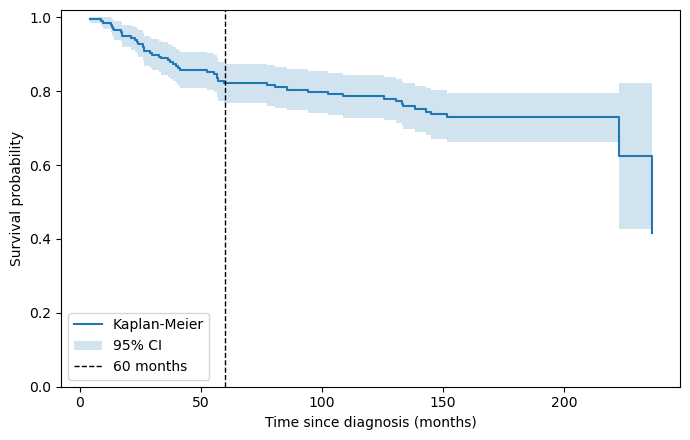

S_hat(60 months) = 0.821  95% CI [0.767, 0.875]
Median survival time: 236.1 months


In [5]:
t_km, s_km, lo_km, hi_km = km_curve(T, E)

plt.figure(figsize=(7, 4.5))
plt.step(t_km, s_km, where="post", label="Kaplan-Meier")
plt.fill_between(t_km, lo_km, hi_km, step="post", alpha=0.2, label="95% CI")
plt.axvline(60, color="black", linestyle="--", linewidth=1, label="60 months")
plt.xlabel("Time since diagnosis (months)")
plt.ylabel("Survival probability")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

s60 = survival_at(t_km, s_km, 60)
lo60 = survival_at(t_km, lo_km, 60)
hi60 = survival_at(t_km, hi_km, 60)
median_time = median_survival_time(t_km, s_km)

print(f"S_hat(60 months) = {s60:.3f}  95% CI [{lo60:.3f}, {hi60:.3f}]")
if median_time is None:
    print("Median survival time: not reached")
else:
    print(f"Median survival time: {median_time:.1f} months")

**Your interpretation:**



Kaplan-Meier estimate at 60 Months: 0.821
95% CI: [0.767, 0.875]
Median survival time is reached at 236.1 months where the KM graph falls below 50%.

The patients remain metastasis free for at least 60 months with a probability of 82.1%. 50% of the patients experienced metastasis about 236 months or 19.7 years after diagnosis .

# Problem 3: DeepSurv-Style Neural Network

In this problem, you will train a small feed-forward neural network to output a scalar risk score $\eta_\theta(x)$. The network is trained with the negative Cox partial log-likelihood.

Use the convention that larger $\eta_\theta(x)$ means higher hazard and therefore shorter expected survival.

## 3.1 Preprocess the Data

The code below:

- one-hot encodes categorical features
- creates train, validation, and test splits stratified by event status
- standardizes features using the training set only

In [6]:
X = X_raw.copy()

# Treat the clinical columns er and grade as categorical if they are present.
# Some versions of scikit-survival store them as numeric codes.
explicit_cat_cols = [c for c in ["er", "grade"] if c in X.columns]
for c in explicit_cat_cols:
    X[c] = X[c].astype(str)

inferred_cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cat_cols = sorted(set(explicit_cat_cols + inferred_cat_cols))

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X = X.astype(float)

indices = np.arange(len(X))
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=1, stratify=E
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=2, stratify=E[train_val_idx]
)

mean = X.iloc[train_idx].mean()
std = X.iloc[train_idx].std().replace(0, 1)
X_std = (X - mean) / std

X_train = X_std.iloc[train_idx].to_numpy(dtype=np.float32)
X_val = X_std.iloc[val_idx].to_numpy(dtype=np.float32)
X_test = X_std.iloc[test_idx].to_numpy(dtype=np.float32)

T_train, T_val, T_test = T[train_idx], T[val_idx], T[test_idx]
E_train, E_val, E_test = E[train_idx], E[val_idx], E[test_idx]

Xtr = torch.tensor(X_train, dtype=torch.float32, device=device)
Xva = torch.tensor(X_val, dtype=torch.float32, device=device)
Xte = torch.tensor(X_test, dtype=torch.float32, device=device)

Ttr = torch.tensor(T_train, dtype=torch.float32, device=device)
Tva = torch.tensor(T_val, dtype=torch.float32, device=device)
Tte = torch.tensor(T_test, dtype=torch.float32, device=device)

Etr = torch.tensor(E_train.astype(np.float32), dtype=torch.float32, device=device)
Eva = torch.tensor(E_val.astype(np.float32), dtype=torch.float32, device=device)
Ete = torch.tensor(E_test.astype(np.float32), dtype=torch.float32, device=device)

print("Train / val / test sizes:", len(train_idx), len(val_idx), len(test_idx))
print("Number of input features:", Xtr.shape[1])

Train / val / test sizes: 118 40 40
Number of input features: 82


## 3.2 Implement the Model and Cox Loss

Build a feed-forward network with architecture

$$
p \rightarrow 64 \rightarrow 32 \rightarrow 1.
$$

Use ReLU activations after the hidden layers. The final output should be a single scalar risk score.

For the Cox partial likelihood, the risk set for an event at time $t_i$ contains all patients with observed time at least $t_i$. The implementation below constructs these risk sets directly, which also handles tied event times cleanly.

In [22]:
class DeepSurv(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # TODO: define a p -> 64 -> 32 -> 1 feed-forward network.
        # Use ReLU activations after the hidden layers and no activation after
        # the final layer, because the output is a scalar risk score.

        self.net = torch.nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )


    def forward(self, x):
        return self.net(x).squeeze(-1)


def neg_cox_partial_log_likelihood(risk, time, event):
    """
    Mean negative Cox partial log-likelihood.
    Risk is eta_theta(x), where larger values mean higher hazard.
    The event should be 1 for observed events and 0 for censored observations.
    """
    # TODO: implement the negative Cox partial log-likelihood.
    # For each observed event time t_i, the risk set contains all patients
    # with observed time >= t_i. Your implementation should return the mean
    # negative log partial likelihood over observed events.
    risk_set = risk_set = time.unsqueeze(1) <= time.unsqueeze(0) #compares row and column tensor and returns boolean array
    #creates n x n risk-set matrix and compares 
    
    log_sum = torch.logsumexp(risk.unsqueeze(0).masked_fill(~risk_set, float("-inf")), dim =1)
    #replaces every entry that is not in risk set (false) with -inf then applies logsumexp

    LL = (risk - log_sum) * event

    return -LL.sum() / event.sum()

## 3.3 Train With Early Stopping

Train for up to 200 epochs with learning rate `1e-3`. Stop early if validation loss does not improve for 15 epochs.

Because Cox risk sets are global, this implementation uses full-batch optimization. The dataset is small enough that this is practical.

epoch   1 | train loss 4.3392 | val loss 3.4389
epoch  25 | train loss 3.6676 | val loss 3.2500
epoch  50 | train loss 2.2952 | val loss 3.5036
Early stopping at epoch 50.


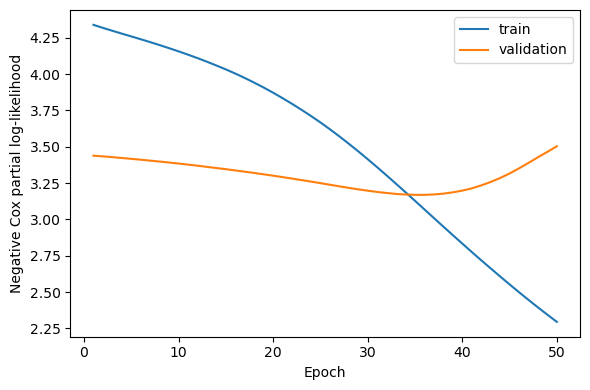

In [23]:
model = DeepSurv(Xtr.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val = np.inf
best_state = None
patience = 0
history = []

for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()

    train_risk = model(Xtr)
    train_loss = neg_cox_partial_log_likelihood(train_risk, Ttr, Etr)

    if not torch.isfinite(train_loss):
        print(f"Stopping at epoch {epoch}: train loss is not finite.")
        break

    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = neg_cox_partial_log_likelihood(model(Xva), Tva, Eva)

    train_value = float(train_loss.detach().cpu().item())
    val_value = float(val_loss.detach().cpu().item())
    history.append((epoch, train_value, val_value))

    if np.isfinite(val_value) and val_value < best_val - 1e-4:
        best_val = val_value
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience = 0
    else:
        patience += 1

    if epoch % 25 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | train loss {train_value:.4f} | val loss {val_value:.4f}")

    if patience >= 15:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
else:
    print("Warning: no finite validation loss was recorded; keeping the final model state.")

if len(history) > 0:
    hist = np.asarray(history)
    plt.figure(figsize=(6, 4))
    plt.plot(hist[:, 0], hist[:, 1], label="train")
    plt.plot(hist[:, 0], hist[:, 2], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Negative Cox partial log-likelihood")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot.")

## 3.4 Evaluate the Model

Implement Harrell's concordance index.

A comparable pair is a pair $(i,j)$ where the patient with the shorter observed time had an observed event. The model is concordant if the patient with the shorter event time has the larger predicted risk score.

Report on the test set:

- Harrell C-index
- negative Cox partial log-likelihood

In [24]:
def harrell_c_index(risk, time, event):
    """Compute Harrell's C-index from risk scores, times, and event indicators."""
    risk = np.asarray(risk, dtype=float)
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)

    # TODO: count comparable pairs.
    # A pair is comparable when the patient with the shorter observed time
    # had an observed event. Count 1.0 for concordant risk ordering and 0.5
    # for tied risk scores.
    
    concordant = 0.0
    comparable = 0.0

    n = len(time)
    
    for i in range(n):
        for j in range(i+1, n):
            if time[i] < time[j] and event[i]:
                
                comparable += 1
                
                if risk[i] > risk[j]:

                    concordant += 1
                    
                elif risk[i] == risk[j]:

                    concordant += 0.5

            elif time[j] < time[i] and event[j]:

                comparable += 1
                
                if risk[j] > risk[i]:

                    concordant += 1

                elif risk[j] == risk[i]:

                    concordant += 0.5

    
    return concordant / comparable

In [28]:
model.eval()
with torch.no_grad():
    risk_test = model(Xte)
    test_loss = neg_cox_partial_log_likelihood(risk_test, Tte, Ete).item()

risk_test_np = risk_test.detach().cpu().numpy()
c_test = harrell_c_index(risk_test_np, T_test, E_test)

print(f"Test negative Cox partial log-likelihood: {test_loss:.4f}")
print(f"Test Harrell C-index: {c_test:.3f}")

Test negative Cox partial log-likelihood: 3.2351
Test Harrell C-index: 0.672


**Your interpretation:**

Comment on whether the model appears to rank higher-risk and lower-risk patients better than chance. Mention at least one limitation of this evaluation.

The model appears to rank higher-risk and lower-risk patients better than chance. The Harrel C-index was 0.672 which is greater than 0.5 which would be randomly ranking. For approximately 67.2% of comparable patient pairs, the model correctly assigned a higher risk score to the patient with metastasis earlier.

One limitation of the model is that the C-index only cares about the model's capability to rank patients rather than evaluating whether or not the risk scores are accurately calculated from the survival probabilites. A fairly small test set can also cause more sampling variability.

# Extra Credit: Baseline Survival and Model-Based Curves

Use the trained model to estimate a baseline cumulative hazard with the Breslow estimator:

$$
\hat H_0(t_j) = \sum_{u \le t_j}\frac{d_u}{\sum_{i \in R_u}\exp(\eta_i)}.
$$

Then estimate survival curves for test patients:

$$
\hat S(t \mid x_i) = \exp\left[-\hat H_0(t)\exp(\eta_i)\right].
$$

Plot the average predicted survival curve for the test set and overlay the Kaplan-Meier curve for the test set.

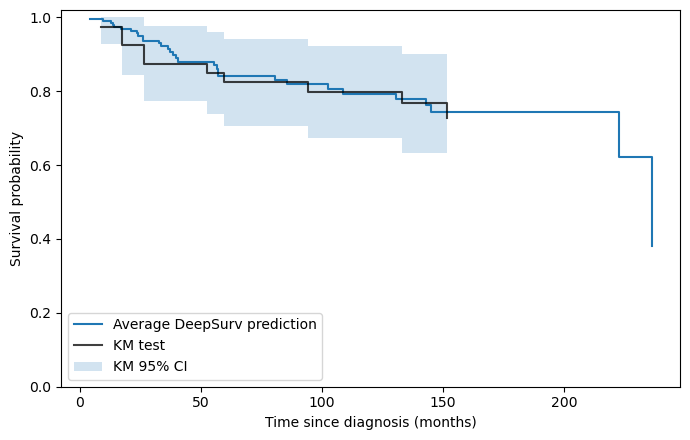

Average predicted S(60 months): 0.841
KM test S(60 months): 0.825
Last event time: 151.72073921971253
Last follow-up time: 231.85215605749485


In [36]:
def breslow_baseline_cumulative_hazard(time, event, eta):
    """Estimate baseline cumulative hazard using Breslow's estimator."""
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)
    eta = np.asarray(eta, dtype=float)

    event_times = np.sort(np.unique(time[event]))
    cumulative_hazard = []
    h0 = 0.0

    for t_j in event_times:
        # TODO: compute d_j and the denominator over the risk set.
        # TODO: update h0 and append the cumulative baseline hazard.
        d_j = np.sum((time == t_j) & event)

        risk_set = time >= t_j

        denom = np.sum(np.exp(eta[risk_set]))

        h0 += d_j / denom

        cumulative_hazard.append(h0)

    return event_times, np.asarray(cumulative_hazard)


with torch.no_grad():
    eta_train = model(Xtr).detach().cpu().numpy()
    eta_test = model(Xte).detach().cpu().numpy()

# Shift both train and test linear predictors by the same constant before
# exponentiating. The product H0(t) * exp(eta) is unchanged, but this avoids
# overflow if the neural network produces large risk scores.
eta_shift = np.max(eta_train)
eta_train_shifted = eta_train - eta_shift
eta_test_shifted = eta_test - eta_shift

t_base, H0 = breslow_baseline_cumulative_hazard(T_train, E_train, eta_train_shifted)

# TODO: use H0 and eta_test_shifted to compute predicted survival curves for
# all test patients, then average those curves over the test set.
# Hint: each row of surv_curves_test should be one patient's survival curve.
surv_curves_test = np.exp(-H0[None, :] * np.exp(eta_test_shifted)[:, None])
avg_surv_test = surv_curves_test.mean(axis=0)

if avg_surv_test is None:
    raise NotImplementedError("Compute the average predicted survival curve for the test set.")






t_km_test, s_km_test, lo_test, hi_test = km_curve(T_test, E_test)

plt.figure(figsize=(7, 4.5))
plt.step(t_base, avg_surv_test, where="post", label="Average DeepSurv prediction")
plt.step(t_km_test, s_km_test, where="post", color="black", alpha=0.75, label="KM test")
plt.fill_between(t_km_test, lo_test, hi_test, step="post", alpha=0.2, label="KM 95% CI")
plt.xlabel("Time since diagnosis (months)")
plt.ylabel("Survival probability")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

pred_s60 = survival_at(t_base, avg_surv_test, 60)
km_s60 = survival_at(t_km_test, s_km_test, 60)
print(f"Average predicted S(60 months): {pred_s60:.3f}")
print(f"KM test S(60 months): {km_s60:.3f}")

**Extra-credit interpretation:**

Compare the model-based average survival curve with the Kaplan-Meier curve on the test set. Are they close? Where do they differ most?

The DeepSurv Survival curve and Kaplan-Meier curve are very close for the first 150 months. The average predicted S and KM score were 84.1% and 82.5% which is only a 1.6% difference in prediction. The main area of difference is from 0-40 months and after 150 months there is no KM curve due to the last event time occuring around 150 months.